In [1]:
using LinearAlgebra, QuantumOptics, DifferentialEquations, Plots, SparseArrays, JLD2, FileIO

## 2 atoms Encoding

### Initialization

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

In [3]:
α = -sqrt(0.82)
β = sqrt(1 - α^2)
ψ_1 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_2 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [4]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2

    σx_1r_atom2 = I2 ⊗ σx_1r
    σx_0r_atom2 = I2 ⊗ σx_0r
    n_r_atom2 = I2 ⊗ n_r
    nn_r12 = n_r ⊗ n_r

    return (σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r12)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r12 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* nn_r12) #+
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [5]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [6]:
tspan = [0.0:0.1:(2π+sqrt(2)π);];
# tspan = [0.0:0.1:100;]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [7]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []


k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2)
n0_atom2 = (I2 ⊗ n0)
n1_atom1 = (n1 ⊗ I2)
n1_atom2 = (I2 ⊗ n1)
nr_atom1 = (nr ⊗ I2)
nr_atom2 = (I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
end

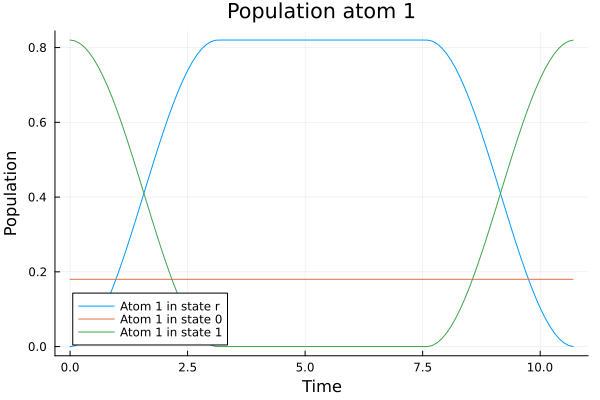

In [8]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

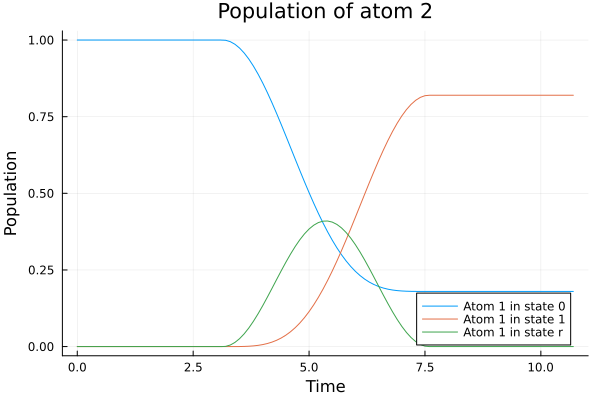

In [9]:
plot(tspan,pop0_atom2, label="Atom 1 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 1 in state 1")
plot!(tspan,popr_atom2, label="Atom 1 in state r")


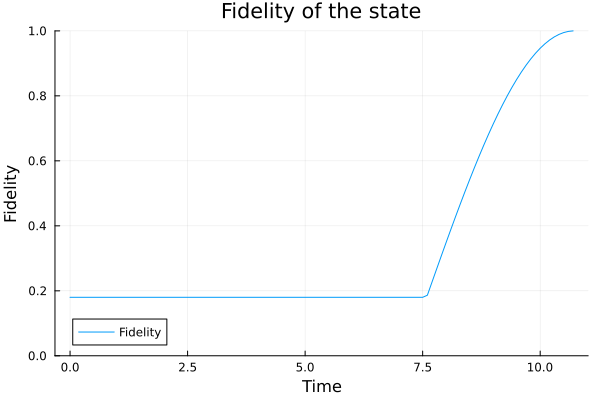

In [10]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b]) + β .* reduce(kron,[a,a])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data))))
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

## 3 atoms Encoding

### Initialization

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = sqrt(0.5)
β = sqrt(1 - α^2)
ψ_2 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_1 = a
ψ_3 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_0r_atom1 = σx_0r ⊗ I2 ⊗ I2
    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2
    n_r_atom1 = n_r ⊗ I2 ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2


    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r
    σx_0r_atom3 = I2 ⊗ I2 ⊗ σx_0r
    n_r_atom3 = I2 ⊗ I2 ⊗ n_r
    nn_r23 = I2 ⊗ n_r ⊗ n_r

    return (σx_0r_atom1, σx_1r_atom1, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom3, nn_r12, nn_r23)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_0r_atom1, σx_1r_atom1, σx_1r_atom2, σx_0r_atom3, σx_1r_atom3, n_r_atom1, n_r_atom3, nn_r12, nn_r23 = ops

    H = (Ω1/2 .* σx_1r_atom2 + Ω2/2 .* (σx_0r_atom1 + σx_1r_atom1) + Δ_0 .* n_r_atom1 + V_nn .* nn_r12 #+
        + Ω2/2 .* (σx_0r_atom3 + σx_1r_atom3) + Δ_0 .* n_r_atom3 + V_nn .* nn_r23)
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [5]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [6]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [7]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))
end

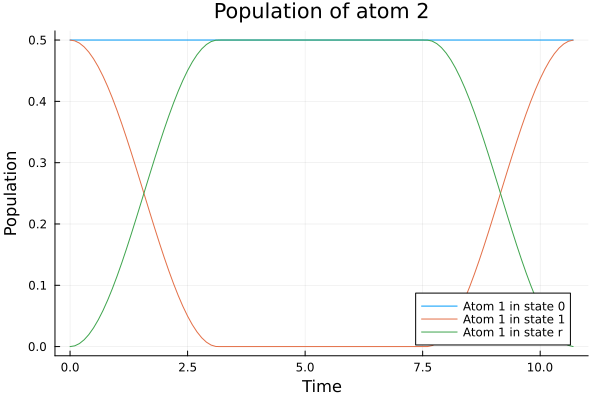

In [8]:
plot(tspan,pop0_atom2, label="Atom 1 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 1 in state 1")
plot!(tspan,popr_atom2, label="Atom 1 in state r")


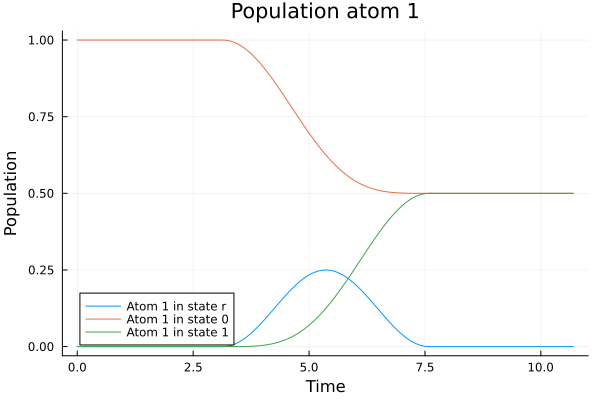

In [9]:
plot(tspan,popr_atom1, label="Atom 1 in state r", title="Population atom 1", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom1, label="Atom 1 in state 0")
plot!(tspan,pop1_atom1,label="Atom 1 in state 1")

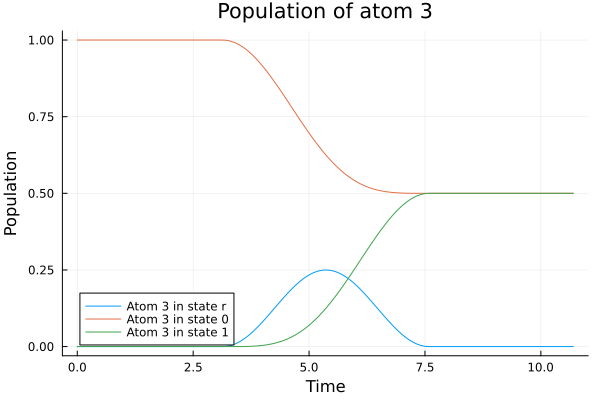

In [10]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

In [11]:
fidelities = []
ψ_target = α .* reduce(kron,[b,b,b]) + β .* reduce(kron,[a,a,a])
# ψ_one = a
# ψ_target = reduce(kron,[ψ_target1,ψ_one])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data)))^2)
end


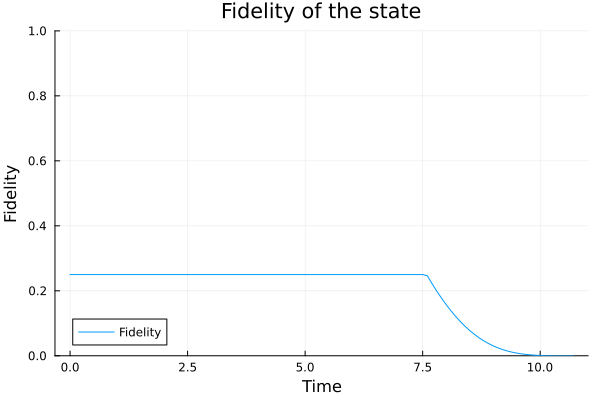

In [12]:
plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

## 3 atoms Ancilla Encoding

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

# α = 1
# β = sqrt(1 - α^2)
# ψ_2 = α .* b + β .* a; #Qubit state |ψ_1>
ψ_1 = b
ψ_2 = a
ψ_3 = a

ψ_a_op = Ket(NLevelBasis(3),ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2) ⊗ Ket(NLevelBasis(3), ψ_3)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>


    σx_1r_atom1 = σx_1r ⊗ I2 ⊗ I2

    σx_0r_atom2 = I2 ⊗ σx_0r ⊗ I2
    σx_1r_atom2 = I2 ⊗ σx_1r ⊗ I2
    n_r_atom2 = I2 ⊗ n_r ⊗ I2
    nn_r12 = n_r ⊗ n_r ⊗ I2
    nn_r23 = I2 ⊗ n_r ⊗ n_r

    σx_1r_atom3 = I2 ⊗ I2 ⊗ σx_1r

    return (σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_1r_atom3, n_r_atom2, nn_r12, nn_r23)
end

const ops = Precomputed_ops();


function Ht(t)
    if t <= π
        Ω1 = 1.0
        Ω2 = 0.0
    elseif t < (π+sqrt(2)π)
        Ω1 = 0.0
        Ω2 = 1.0
    else 
        Ω1 = 1.0
        Ω2 = 0.0
    end

    σx_1r_atom1, σx_0r_atom2, σx_1r_atom2, σx_1r_atom3, n_r_atom2, nn_r12, nn_r23 = ops

    H = (Ω1/2 .* σx_1r_atom1 + Ω1/2 .* σx_1r_atom3 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* (nn_r12 + nn_r23))
    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
const Δ_0 = -1000
const Ω1 = 1.0
const Ω2 = 1.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [5]:
# tspan = [0.0:0.1:(3.5π);];
tspan = [0.0:0.1:(2π+sqrt(2)π);]
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []

popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

popr_atom3 = []
pop0_atom3 = []
pop1_atom3 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2 ⊗ I2)
n0_atom2 = (I2 ⊗ n0 ⊗ I2)
n0_atom3 = (I2 ⊗ I2 ⊗ n0)

n1_atom1 = (n1 ⊗ I2 ⊗ I2)
n1_atom2 = (I2 ⊗ n1 ⊗ I2)
n1_atom3 = (I2 ⊗ I2 ⊗ n1)

nr_atom1 = (nr ⊗ I2 ⊗ I2)
nr_atom2 = (I2 ⊗ nr ⊗ I2)
nr_atom3 = (I2 ⊗ I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
    
    push!(pop0_atom3, real(tr(n0_atom3*ρ)))
    push!(pop1_atom3, real(tr(n1_atom3*ρ)))
    push!(popr_atom3, real(tr(nr_atom3*ρ)))
end

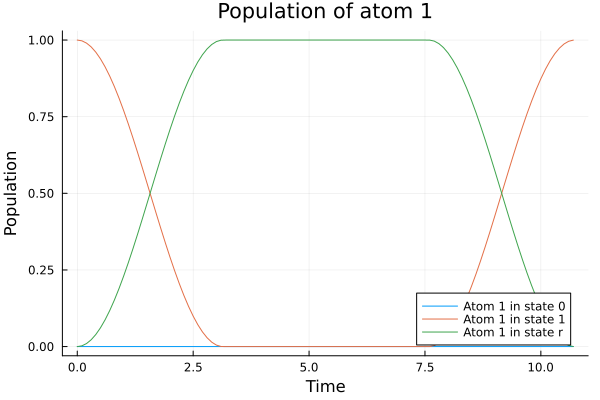

In [7]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1")
plot!(tspan,popr_atom1, label="Atom 1 in state r")


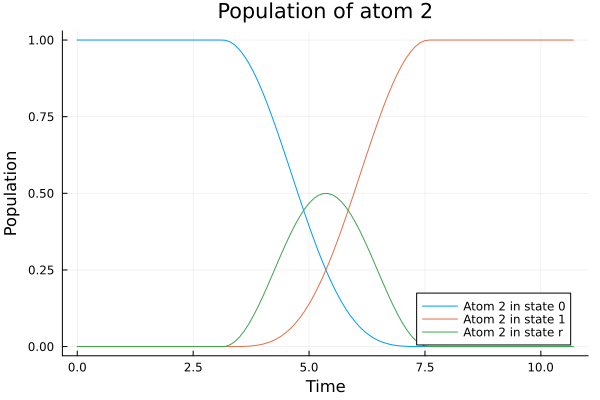

In [8]:
plot(tspan,pop0_atom2, label="Atom 2 in state 0", title="Population of atom 2", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom2, label="Atom 2 in state 1")
plot!(tspan,popr_atom2, label="Atom 2 in state r")


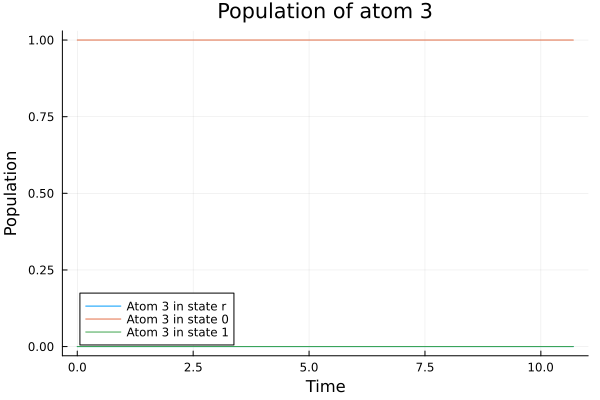

In [9]:
plot(tspan,popr_atom3, label="Atom 3 in state r", title="Population of atom 3", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom3, label="Atom 3 in state 0")
plot!(tspan,pop1_atom3,label="Atom 3 in state 1")

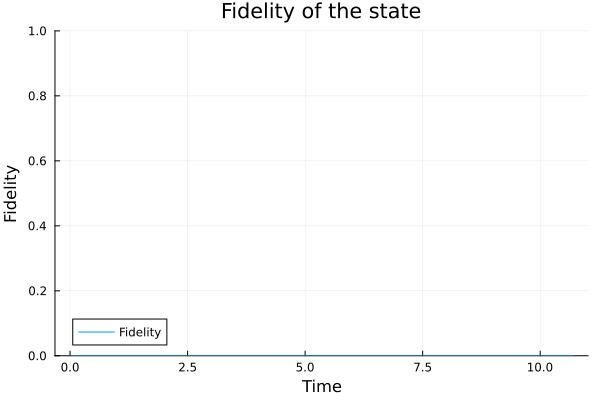

In [26]:
fidelities = []
ψ_target = reduce(kron,[b,b,a])
ρ_target = ψ_target * ψ_target'

for ρ in sol
    push!(fidelities,tr(sqrt(sqrt(ρ.data)*ρ_target*sqrt(ρ.data)))^2)
end

plot(tspan,real(fidelities),ylim=[0,1],label="Fidelity", title="Fidelity of the state", xlabel="Time", ylabel="Fidelity",legend=:bottomleft)

In [ ]:
round.(real.(sol[end].data);digits=1)

27×27 Matrix{Float64}:
 0.0   0.0   0.0  0.0   0.0   0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0  -0.0  0.0  -0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  -0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  -0.0   0.0  0.0   1.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0   0.0  0.0   0.0   0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  -0.0  -0.0  0.0  -0.0  -0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0  -0.0  0.0  -0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                            ⋮         ⋱  ⋮                        ⋮    
 0.0   0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0   0.0  0.0   0.0   0.0  0.0     0.0  0.0  0.0

In [25]:
round.(real.(ρ_target);digits=1)

27×27 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱  ⋮                        ⋮    
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     